# 4. Обучаемый фильтр

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, freqz
plt.rcParams.update({'font.size': 13, 'figure.figsize': (10, 3.8),
                     'axes.grid': True, 'axes.unicode_minus': False})

import torch
from torch import nn
from torch.nn import functional as F
from copy import deepcopy
torch.manual_seed(42)
torch.set_num_threads(2)

## 4.1 Известное правило и обучаемые веса
Прогноз = вес * вход

In [2]:
x_one, target_one = 2.0,1.0
weight = 1.5
print('Вход:',x_one)
print('Цель:',target_one)
print('Вес:',weight)
print('Прогноз:',weight*x_one)

Вход: 2.0
Цель: 1.0
Вес: 1.5
Прогноз: 3.0


## 4.2 Что считается правильным ответом
Вход - случайная запись; цель - выход цифрового фильтра

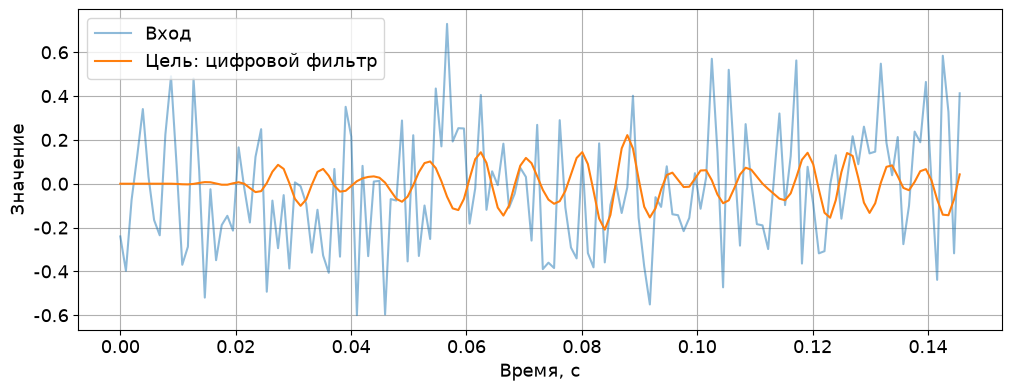

In [3]:
K, fs = 65,1024.0
h = firwin(K,[80.0,160.0],pass_zero=False,fs=fs,window=('kaiser',8))
rng = np.random.default_rng(5)
x_example = rng.normal(0,0.3,512)
y_example = lfilter(h,[1.0],x_example)
fig, ax = plt.subplots(layout='constrained')
ax.plot(np.arange(150)/fs,x_example[:150],alpha=0.5,label='Вход')
ax.plot(np.arange(150)/fs,y_example[:150],label='Цель: цифровой фильтр')
ax.set(xlabel='Время, с',ylabel='Значение'); ax.legend()
plt.show()

## 4.3 Три набора данных
Train меняет веса, validation выбирает состояние, test оценивает результат

In [4]:
train_seed, val_seed, test_seed = 10,20,30
train_array = np.random.default_rng(train_seed).normal(0,0.3,(32,512)).astype(np.float32)
print('Форма обучающего массива:',train_array.shape)
print('Начало первой записи:',train_array[0,:8])

Форма обучающего массива: (32, 512)
Начало первой записи: [-0.33100152 -0.21750739 -0.23454158  0.08009276 -0.07457422  0.03794492
  0.25291276  0.25738096]


## 4.4 От массива к тензору
Запись, канал, отсчет

In [5]:
with_channel = train_array[:,None,:]
tensor = torch.from_numpy(with_channel)
print('NumPy:',train_array.shape)
print('С осью канала:',with_channel.shape)
print('PyTorch:',tuple(tensor.shape),tensor.dtype)
print('Первые отсчеты:',tensor[0,0,:8])

NumPy: (32, 512)
С осью канала: (32, 1, 512)
PyTorch: (32, 1, 512) torch.float32
Первые отсчеты: tensor([-0.3310, -0.2175, -0.2345,  0.0801, -0.0746,  0.0379,  0.2529,  0.2574])


In [6]:
def make_pairs(seed,count,length,h):
    rng = np.random.default_rng(seed)
    x = rng.normal(0 ,0.3,(count,length)).astype(np.float32)
    y = lfilter(h,[1.0],x,axis=-1).astype(np.float32)
    return torch.from_numpy(x[:,None,:]),torch.from_numpy(y[:,None,:])

In [7]:
train_x,train_y = make_pairs(train_seed,32,512,h)
val_x,val_y = make_pairs(val_seed,8,512,h)
print('Вход и цель:',tuple(train_x.shape),tuple(train_y.shape))

Вход и цель: (32, 1, 512) (32, 1, 512)


## 4.5 Один сверточный слой
Одинаковые веса во всех позициях; нули добавляются только слева

In [8]:
recent = np.array([4.,2.,1.])  # текущий, предыдущий, еще один предыдущий
h_small = np.array([0.2,0.3,0.5])
print('В порядке задержек:',np.sum(h_small*recent))
print('Окно слева направо:',recent[::-1])
print('Веса слоя слева направо:',h_small[::-1])
print('Та же сумма:',np.sum(h_small[::-1]*recent[::-1]))

В порядке задержек: 1.9
Окно слева направо: [1. 2. 4.]
Веса слоя слева направо: [0.5 0.3 0.2]
Та же сумма: 1.9000000000000001


In [9]:
class LearnedFIR(nn.Module):
    def __init__(self,taps):
        super().__init__()
        self.taps = taps
        self.conv = nn.Conv1d(1,1,taps,bias=False)

    def forward(self,x):
        return self.conv(F.pad(x,(self.taps-1,0)))

In [10]:
model = LearnedFIR(K)
print(model)
print('Обучаемых весов:',sum(p.numel() for p in model.parameters()))
print('Вход:',tuple(val_x.shape))
print('После дополнения:',tuple(F.pad(val_x,(K-1,0)).shape))

LearnedFIR(
  (conv): Conv1d(1, 1, kernel_size=(65,), stride=(1,), bias=False)
)
Обучаемых весов: 65
Вход: (8, 1, 512)
После дополнения: (8, 1, 576)


## 4.6 Прогноз и ошибка
MSE: разность, квадрат, среднее

Ошибки: tensor([ 1., -1.,  0.])
Квадраты: tensor([1., 1., 0.])
MSE: 0.6666666865348816
Форма выхода: (8, 1, 512)
MSE до обучения: 0.04174961522221565


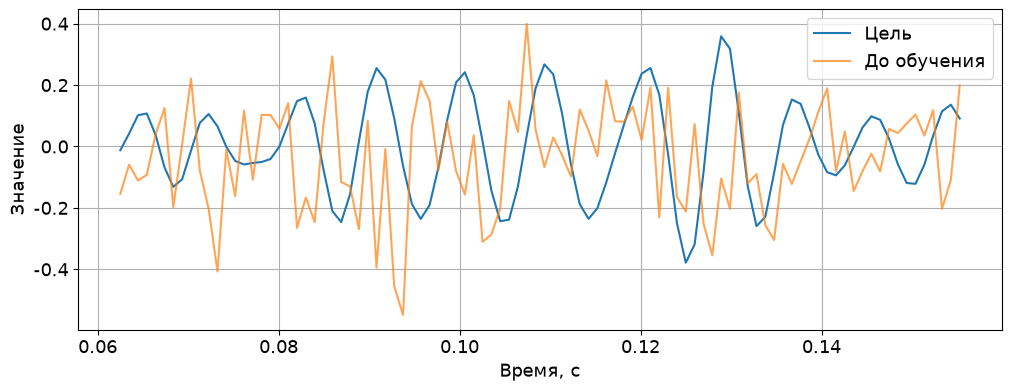

In [11]:
errors = torch.tensor([1.,-1.,0.])
print('Ошибки:',errors)
print('Квадраты:',errors**2)
print('MSE:',torch.mean(errors**2).item())
with torch.no_grad():
    before = model(val_x)
print('Форма выхода:',tuple(before.shape))
print('MSE до обучения:',torch.mean((before[...,K-1:]-val_y[...,K-1:])**2).item())
fig, ax = plt.subplots(layout='constrained')
ax.plot(np.arange(K-1,160)/fs,val_y[0,0,K-1:160],label='Цель')
ax.plot(np.arange(K-1,160)/fs,before[0,0,K-1:160],label='До обучения',alpha=0.7)
ax.set(xlabel='Время, с',ylabel='Значение'); ax.legend()
plt.show()

## 4.7 Градиент и один шаг обучения
Один вес: 1.5 -> 0.7; ошибка: 4 -> 0.16

In [12]:
w = torch.tensor(1.5,requires_grad=True)
scalar_optimizer = torch.optim.SGD([w],lr=0.1)
scalar_optimizer.zero_grad()
scalar_loss = (w*2-1)**2
scalar_loss.backward()
print('Вес до:',w.item(),'Ошибка до:',scalar_loss.item())
print('Градиент:',w.grad.item())
scalar_optimizer.step()
print('Вес после:',w.item(),'Ошибка после:',((w*2-1)**2).item())

Вес до: 1.5 Ошибка до: 4.0
Градиент: 8.0
Вес после: 0.699999988079071 Ошибка после: 0.15999998152256012


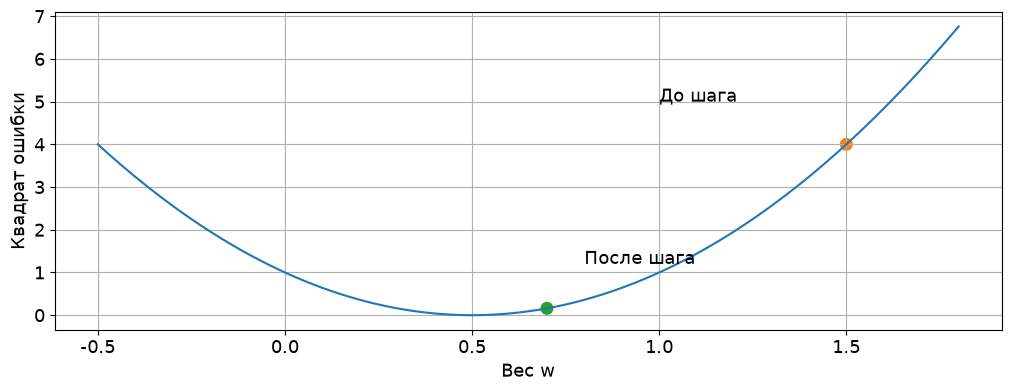

In [13]:
weights = np.linspace(-0.5,1.8,200)
fig, ax = plt.subplots(layout='constrained')
ax.plot(weights,(2*weights-1)**2)
ax.scatter([1.5,0.7],[4,0.16],color=['C1','C2'],s=70)
ax.annotate('До шага',(1.5,4),xytext=(1.0,5))
ax.annotate('После шага',(0.7,0.16),xytext=(0.8,1.2))
ax.set(xlabel='Вес w',ylabel='Квадрат ошибки')
plt.show()

## 4.8 Эпохи и выбор состояния
Сохраняется состояние с наименьшей validation MSE

In [14]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.03)
criterion = nn.MSELoss()
train_history, val_history = [],[]
best_loss = float('inf')
best_state = deepcopy(model.state_dict())
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(train_x)[...,K-1:],train_y[...,K-1:])
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(train_x)[...,K-1:],train_y[...,K-1:]).item()
        val_loss = criterion(model(val_x)[...,K-1:],val_y[...,K-1:]).item()
    train_history.append(train_loss)
    val_history.append(val_loss)
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = deepcopy(model.state_dict())
model.load_state_dict(best_state)
print('Лучшая validation MSE:',best_loss)

Лучшая validation MSE: 1.3212525691586041e-11


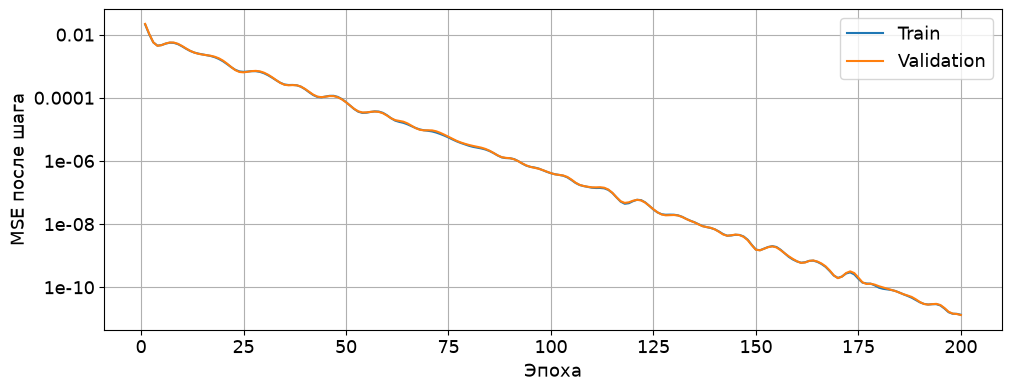

In [15]:
import matplotlib.ticker as mticker
fig, ax = plt.subplots(layout='constrained')
ax.semilogy(np.arange(1,len(train_history)+1),train_history,label='Train')
ax.semilogy(np.arange(1,len(val_history)+1),val_history,label='Validation')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda value,pos:f'{value:g}'))
ax.set(xlabel='Эпоха',ylabel='MSE после шага'); ax.legend()
plt.show()

## 4.9 Проверка на новых данных
Три варианта сравниваются с одним эталоном

In [16]:
test_x,test_y = make_pairs(test_seed,8,512,h)

In [17]:
model.eval()
with torch.no_grad():
    prediction = model(test_x)
truth = test_y[...,K-1:]
metrics = {
    'Нулевой выход':torch.mean(truth**2).item(),
    'Без фильтрации':torch.mean((test_x[...,K-1:]-truth)**2).item(),
    'Модель':torch.mean((prediction[...,K-1:]-truth)**2).item(),
}
for name,value in metrics.items():
    print(f'{name}: MSE={value:.8g}')

Нулевой выход: MSE=0.010621862
Без фильтрации: MSE=0.098074369
Модель: MSE=1.3477931e-11


## 4.10 Выход, коэффициенты и спектр
Вход - широкополосная случайная запись; цель - ее выход после цифрового фильтра

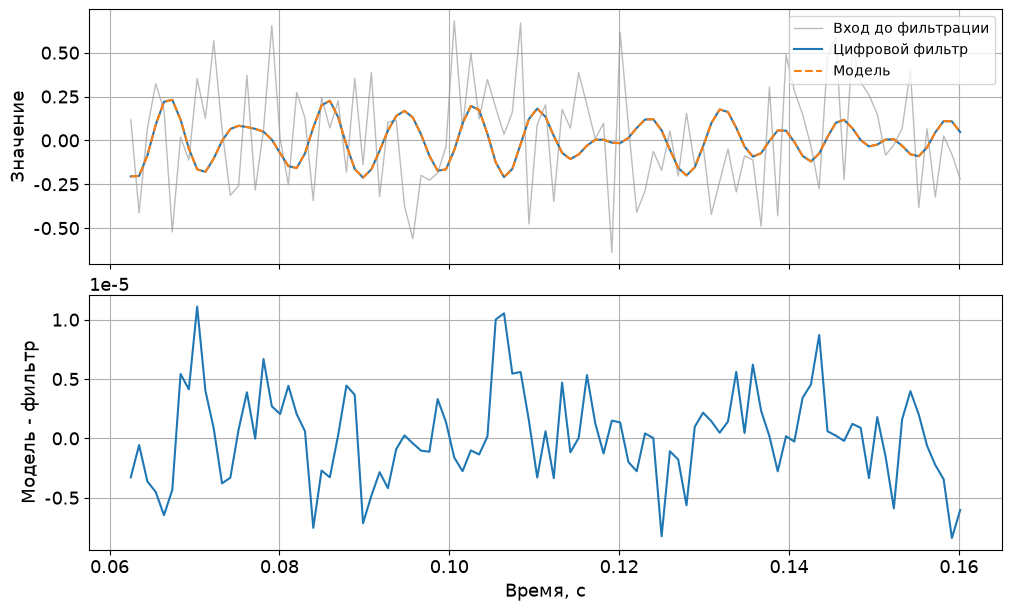

In [18]:
idx = np.arange(K-1,K+100)
fig, axes = plt.subplots(2,1,figsize=(10,6),sharex=True,layout='constrained')
axes[0].plot(idx/fs,test_x[0,0,idx],color='0.6',alpha=0.65,linewidth=1,label='Вход до фильтрации')
axes[0].plot(idx/fs,test_y[0,0,idx],label='Цифровой фильтр')
axes[0].plot(idx/fs,prediction[0,0,idx],'--',label='Модель')
axes[0].set_ylabel('Значение'); axes[0].legend(fontsize=10,loc='upper right')
axes[1].plot(idx/fs,(prediction-test_y)[0,0,idx])
axes[1].set(xlabel='Время, с',ylabel='Модель - фильтр')
plt.show()

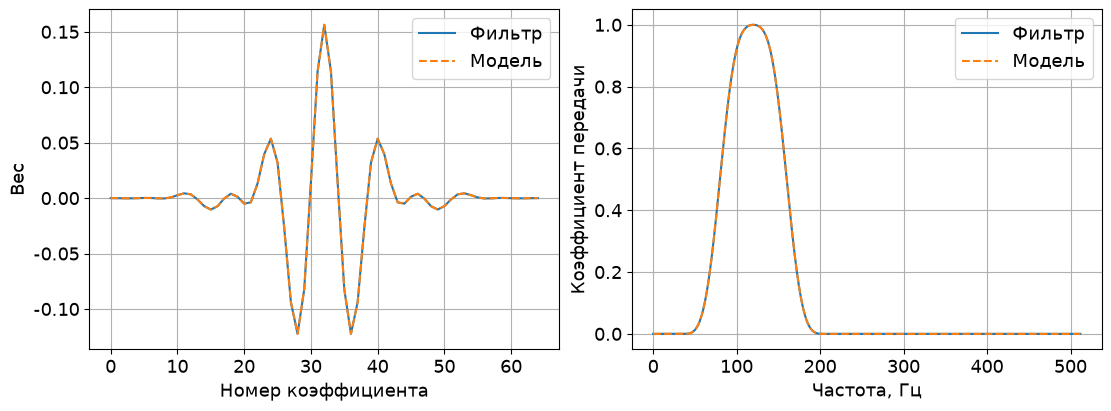

In [19]:
learned_h = model.conv.weight.detach().numpy()[0,0,::-1].copy()
f_response,H = freqz(h,fs=fs,worN=2048)
_,H_model = freqz(learned_h,fs=fs,worN=2048)
fig, axes = plt.subplots(1,2,figsize=(11,4),layout='constrained')
axes[0].plot(h,label='Фильтр')
axes[0].plot(learned_h,'--',label='Модель')
axes[0].set(xlabel='Номер коэффициента',ylabel='Вес'); axes[0].legend()
axes[1].plot(f_response,np.abs(H),label='Фильтр')
axes[1].plot(f_response,np.abs(H_model),'--',label='Модель')
axes[1].set(xlabel='Частота, Гц',ylabel='Коэффициент передачи'); axes[1].legend()
plt.show()

In [20]:
def amplitude(values, fs, hann=False):
    values = np.asarray(values, dtype=float)
    window = np.hanning(len(values)) if hann else np.ones(len(values))
    A = np.abs(np.fft.rfft(values*window))/window.sum()
    if len(values) % 2 == 0:
        A[1:-1] *= 2
    else:
        A[1:] *= 2
    return np.fft.rfftfreq(len(values), d=1/fs), A

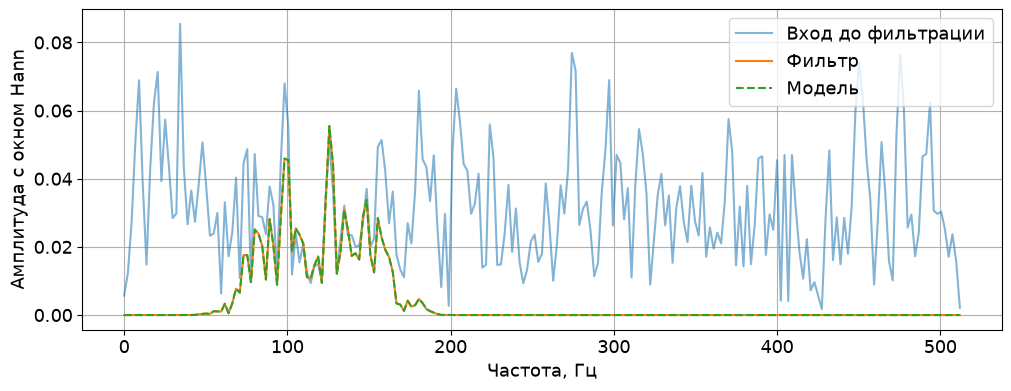

In [21]:
fig, ax = plt.subplots(layout='constrained')
for values,label in [(test_x[0,0,K-1:].numpy(),'Вход до фильтрации'),(test_y[0,0,K-1:].numpy(),'Фильтр'),(prediction[0,0,K-1:].numpy(),'Модель')]:
    f,A = amplitude(values,fs,hann=True)
    ax.plot(f,A,alpha=0.55 if label=='Вход до фильтрации' else 1.0,linestyle='--' if label=='Модель' else '-',label=label)
ax.set(xlabel='Частота, Гц',ylabel='Амплитуда с окном Hann'); ax.legend()
plt.show()

## 4.11 Другая длина и сохранение

In [22]:
new_x,new_y = make_pairs(40,1,1301,h)
with torch.no_grad():
    new_prediction = model(new_x)
print('Вход:',tuple(new_x.shape),'Выход:',tuple(new_prediction.shape))
print('MSE:',torch.mean((new_prediction[...,K-1:]-new_y[...,K-1:])**2).item())

Вход: (1, 1, 1301) Выход: (1, 1, 1301)
MSE: 1.408161000998609e-11


In [23]:
folder = Path('outputs')
folder.mkdir(exist_ok=True)
checkpoint = {'state_dict':model.state_dict(),'taps':K,'fs':fs,'teacher_h':h.tolist()}
torch.save(checkpoint,folder/'demo_filter.pt')
saved = torch.load(folder/'demo_filter.pt',map_location='cpu',weights_only=True)
restored = LearnedFIR(saved['taps'])
restored.load_state_dict(saved['state_dict'])
restored.eval()
with torch.no_grad():
    print('После загрузки совпадает:',torch.allclose(restored(new_x),new_prediction))

После загрузки совпадает: True



Модель повторяет выбранный фильтр на новых записях
